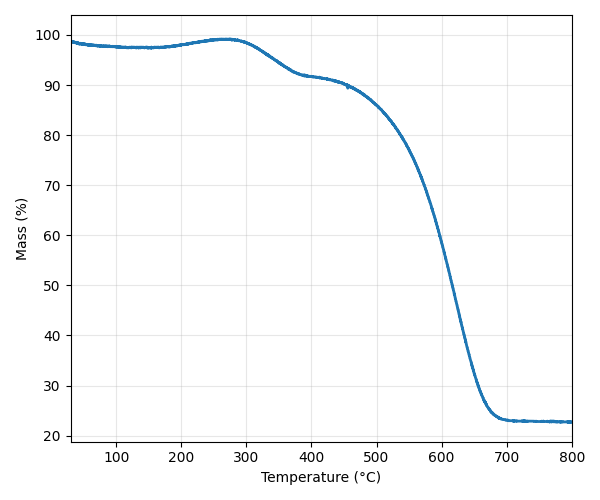

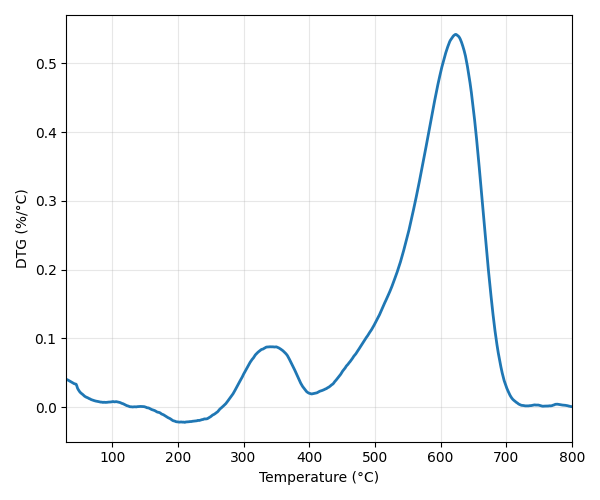

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget


# =========================
# FILE
# =========================

filename = r"H:\FUBerlin\Measurements\TGA_TUB\20260715_TGA_NoPo_AirOx\HiPCo-1_AIR_800_1.txt"


# =========================
# READ TGA TXT
# =========================

with open(filename, "r", encoding="latin1") as f:
    lines = f.readlines()


# find data start
for i, line in enumerate(lines):
    if "Index" in line:
        start = i + 2
        break


data = []

for line in lines[start:]:

    parts = line.split()

    if len(parts) >= 3:

        try:
            temperature = float(parts[1].replace(",", "."))
            mass = float(parts[2].replace(",", "."))

            data.append([temperature, mass])

        except:
            pass


df = pd.DataFrame(
    data,
    columns=["Temperature", "Mass"]
)


# =========================
# PROCESS MASS
# =========================

# keep heating part only
max_idx = df["Temperature"].idxmax()
df = df.loc[:max_idx].copy()


# normalize initial mass
m0 = df["Mass"].head(10).mean()

df["Mass (%)"] = df["Mass"] / m0 * 100



# =========================
# DTG CALCULATION
# =========================

# sort and remove duplicates
df = df.sort_values("Temperature")
df = df.drop_duplicates("Temperature")


# uniform temperature grid
step = 1.0

temp_uniform = np.arange(
    df["Temperature"].min(),
    df["Temperature"].max(),
    step
)


mass_uniform = np.interp(
    temp_uniform,
    df["Temperature"],
    df["Mass (%)"]
)


# smoothing
window = 20

mass_smooth = (
    pd.Series(mass_uniform)
    .rolling(window, center=True, min_periods=1)
    .mean()
    .values
)


# derivative
dtg = np.gradient(
    mass_smooth,
    temp_uniform
)


# TGA convention: mass loss positive
dtg = -dtg


# second smoothing
dtg = (
    pd.Series(dtg)
    .rolling(window, center=True, min_periods=1)
    .mean()
    .values
)



# =========================
# PLOT TGA
# =========================

plt.figure(figsize=(6,5))

plt.plot(
    df["Temperature"],
    df["Mass (%)"],
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Mass (%)")

plt.xlim(30,800)
#plt.ylim(70,101)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# =========================
# PLOT DTG
# =========================

plt.figure(figsize=(6,5))

plt.plot(
    temp_uniform,
    dtg,
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("DTG (%/°C)")

plt.xlim(30,800)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()